## Load Data and Initial Inspection

### Subtask:
Load the 'Vehicle_Insurance.csv' dataset into a pandas DataFrame, display its first few rows, check its information (data types, non-null counts), and show descriptive statistics to understand its structure and content.


In [11]:
import pandas as pd

df = pd.read_csv('Vehicle_Insurance.csv')

print('First 5 rows of the DataFrame:')
print(df.head())

print('\nDataFrame Info:')
df.info()

print('\nDescriptive Statistics:')
print(df.describe())

First 5 rows of the DataFrame:
   id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0   1    Male   44                1         28.0                   0   
1   2    Male   76                1          3.0                   0   
2   3    Male   47                1         28.0                   0   
3   4    Male   21                1         11.0                   1   
4   5  Female   29                1         41.0                   1   

  Vehicle_Age Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  \
0   > 2 Years            Yes         40454.0                  26.0      217   
1    1-2 Year             No         33536.0                  26.0      183   
2   > 2 Years            Yes         38294.0                  26.0       27   
3    < 1 Year             No         28619.0                 152.0      203   
4    < 1 Year             No         27496.0                 152.0       39   

   Response  
0         1  
1         0  
2         1  
3    

## Handle Missing Values

### Subtask:
Identify and display the count of missing values for each column in the DataFrame. If any are found, a strategy for handling them will be determined (e.g., imputation or removal), though based on previous context, there might not be any.


In [12]:
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64


## Convert Categorical Features

### Subtask:
Convert relevant categorical columns ('Gender', 'Vehicle_Age', 'Vehicle_Damage', 'Region_Code', 'Policy_Sales_Channel') to appropriate numerical or categorical data types for better analysis and compatibility with visualization libraries.


In [13]:
categorical_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage', 'Region_Code', 'Policy_Sales_Channel']

for col in categorical_cols:
    df[col] = df[col].astype('category')

print("Data types after converting categorical columns:")
df.info()

Data types after converting categorical columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   id                    381109 non-null  int64   
 1   Gender                381109 non-null  category
 2   Age                   381109 non-null  int64   
 3   Driving_License       381109 non-null  int64   
 4   Region_Code           381109 non-null  category
 5   Previously_Insured    381109 non-null  int64   
 6   Vehicle_Age           381109 non-null  category
 7   Vehicle_Damage        381109 non-null  category
 8   Annual_Premium        381109 non-null  float64 
 9   Policy_Sales_Channel  381109 non-null  category
 10  Vintage               381109 non-null  int64   
 11  Response              381109 non-null  int64   
dtypes: category(5), float64(1), int64(6)
memory usage: 22.5 MB


## Identify Outliers in Numerical Data

### Subtask:
Visualize the distribution of key numerical features such as 'Age', 'Annual_Premium', and 'Vintage' using box plots to identify potential outliers and understand their spread.


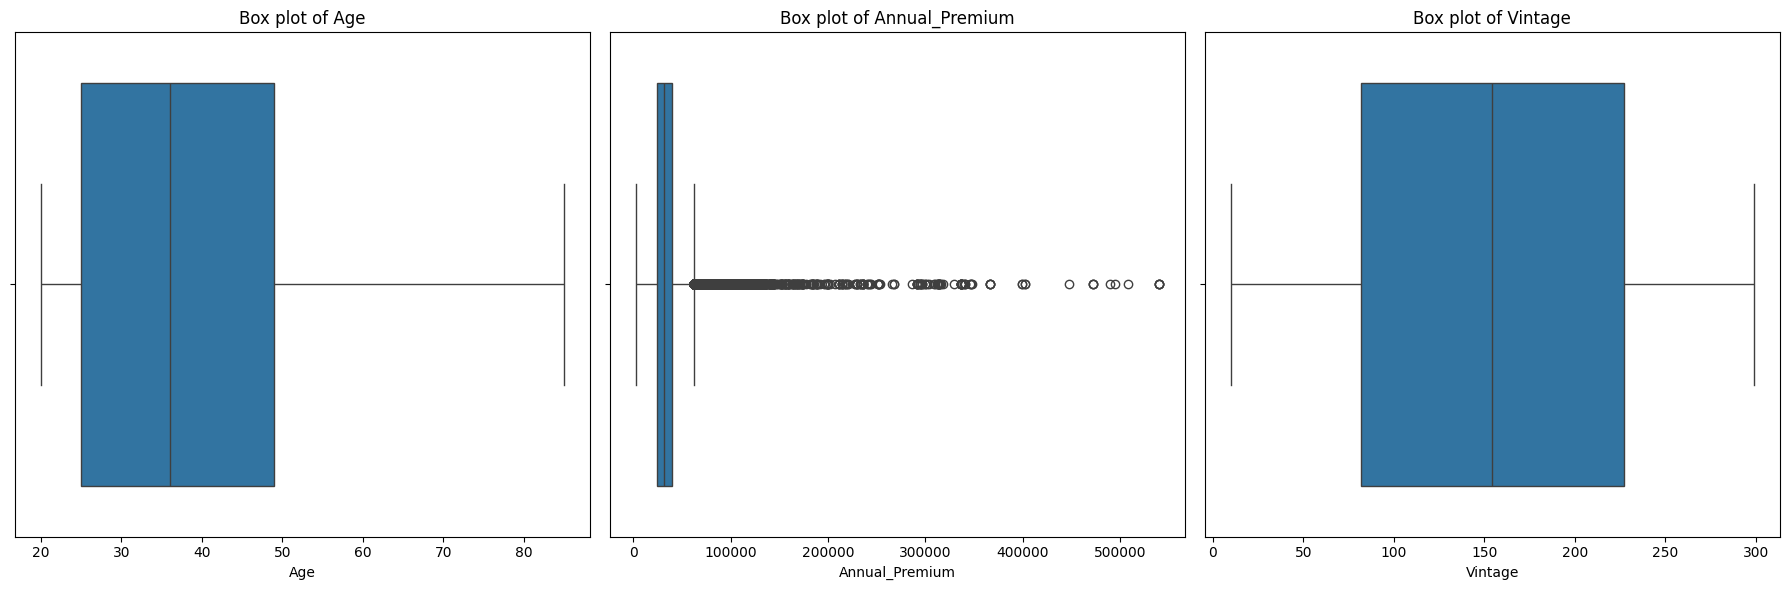

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_for_outliers = ['Age', 'Annual_Premium', 'Vintage']

plt.figure(figsize=(18, 6))
for i, col in enumerate(numerical_cols_for_outliers):
    plt.subplot(1, len(numerical_cols_for_outliers), i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

## Analyze Age Distribution

### Subtask:
Plot a histogram of the 'Age' column to visualize its distribution, including appropriate labels, title, and legend.


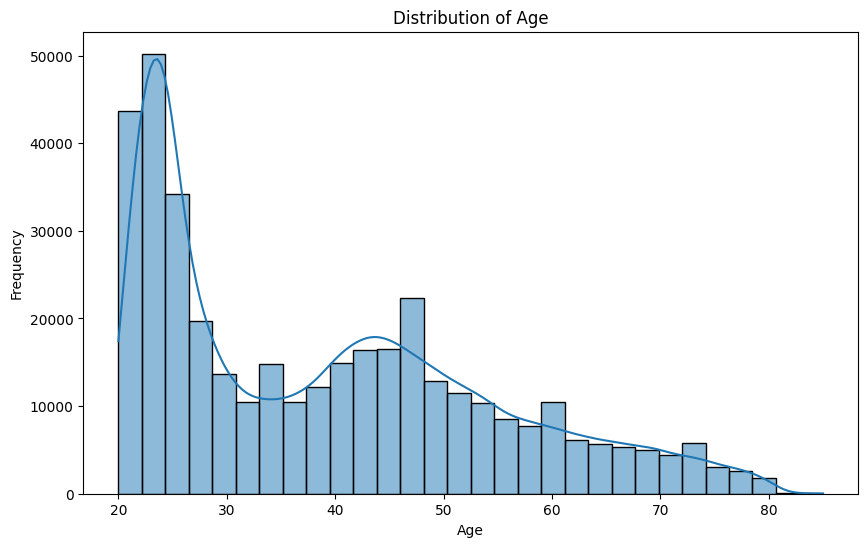

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## Analyze Gender Distribution

### Subtask:
Create a count plot for the 'Gender' column to show the distribution of customers by gender, ensuring proper labels, title, and legend.


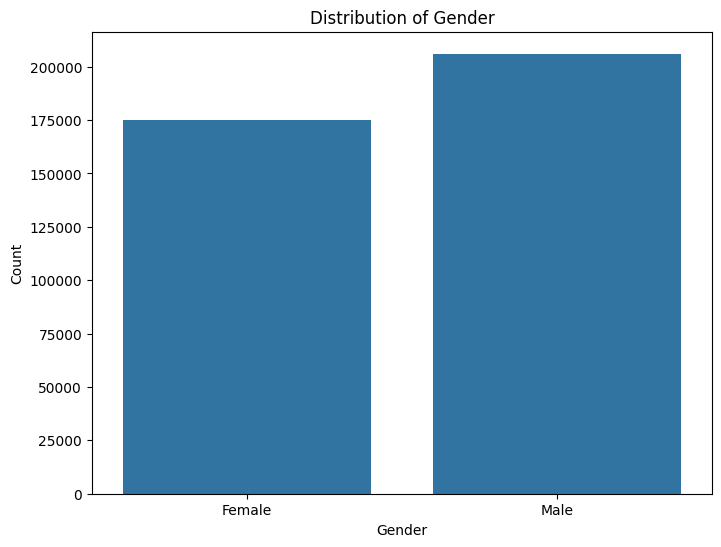

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', data=df)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## Analyze Region Distribution

### Subtask:
Generate a count plot for 'Region_Code' to visualize the distribution of customers across different regions. The plot will order regions by count and include appropriate labels, title, and legend.


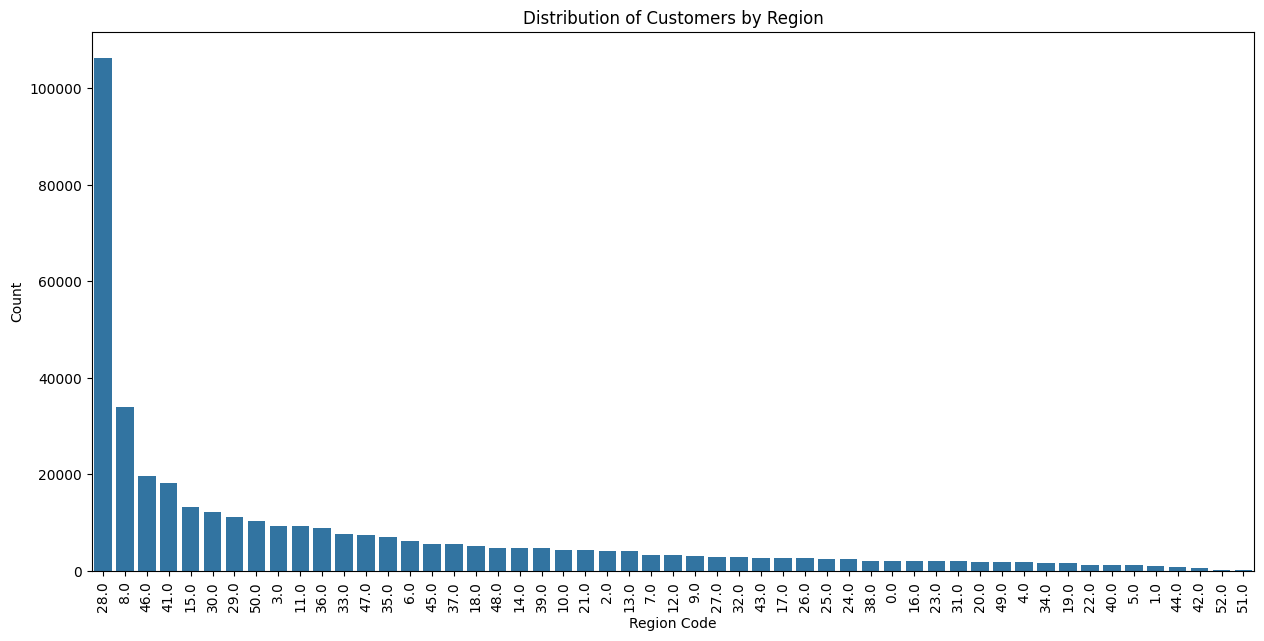

In [17]:
plt.figure(figsize=(15, 7))
sns.countplot(x='Region_Code', data=df, order=df['Region_Code'].value_counts().index)
plt.title('Distribution of Customers by Region')
plt.xlabel('Region Code')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

## Analyze Annual Premium Distribution

### Subtask:
Plot a histogram of the 'Annual_Premium' column to examine its distribution. Consider using a logarithmic scale on the x-axis if outliers are significant to better visualize the central tendency, with proper labels, title, and legend.


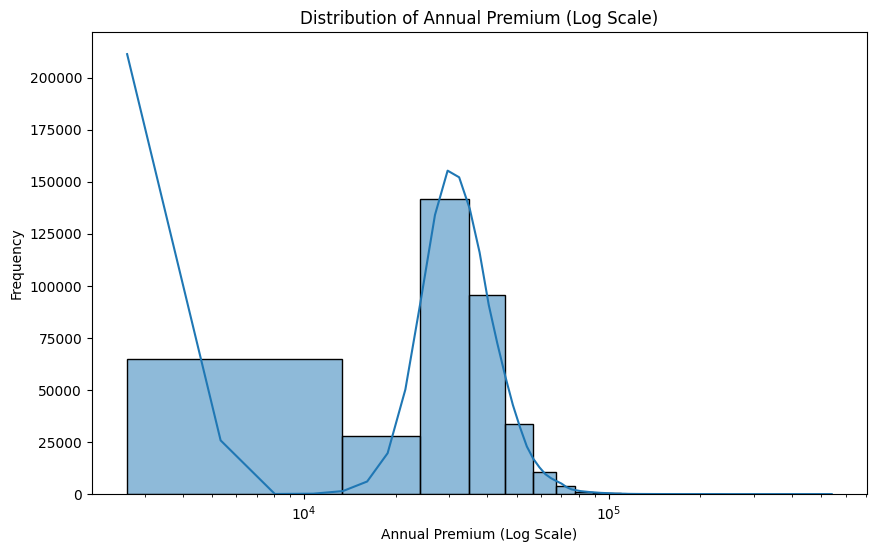

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Annual_Premium'], bins=50, kde=True)
plt.xscale('log')
plt.title('Distribution of Annual Premium (Log Scale)')
plt.xlabel('Annual Premium (Log Scale)')
plt.ylabel('Frequency')
plt.show()

## Analyze Vehicle Age Distribution

### Subtask:
Create a count plot to show the distribution of 'Vehicle_Age' categories, with appropriate labels, title, and legend.


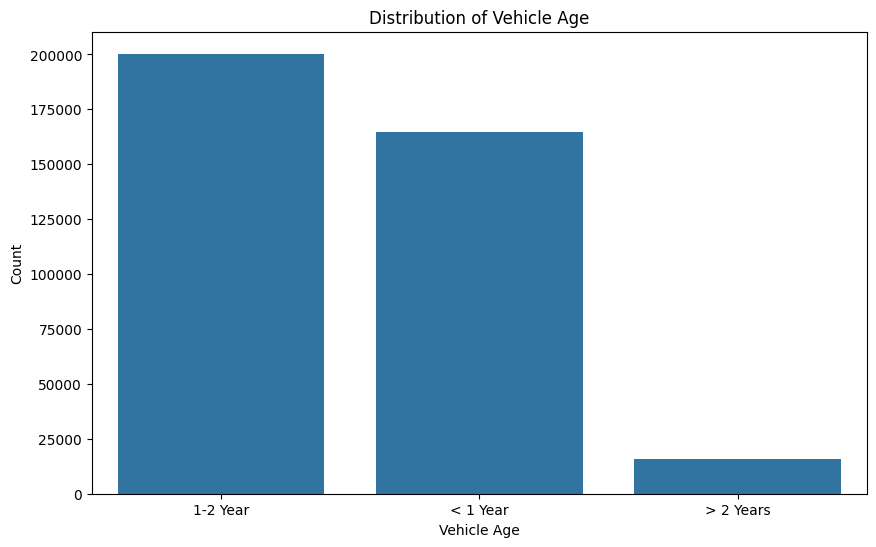

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Vehicle_Age', data=df, order=df['Vehicle_Age'].value_counts().index)
plt.title('Distribution of Vehicle Age')
plt.xlabel('Vehicle Age')
plt.ylabel('Count')
plt.show()

## Analyze Vehicle Damage Distribution

### Subtask:
Generate a count plot for the 'Vehicle_Damage' column to visualize the proportion of vehicles with and without damage, ensuring proper labels, title, and legend.


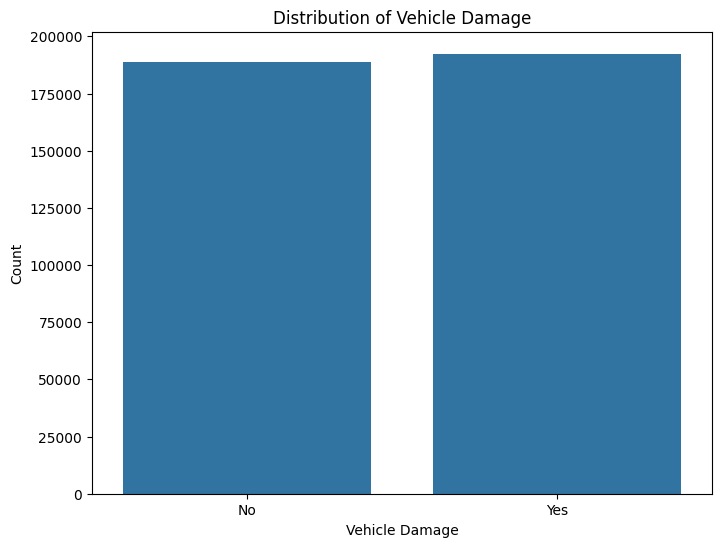

In [20]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Vehicle_Damage', data=df)
plt.title('Distribution of Vehicle Damage')
plt.xlabel('Vehicle Damage')
plt.ylabel('Count')
plt.show()

## Analyze Age vs. Claims

### Subtask:
Examine the relationship between 'Age' and the target variable 'Response' (insurance claims). This could involve grouping by age bins and calculating claim rates, or using plots like box plots of 'Age' grouped by 'Response', with labels and legends.


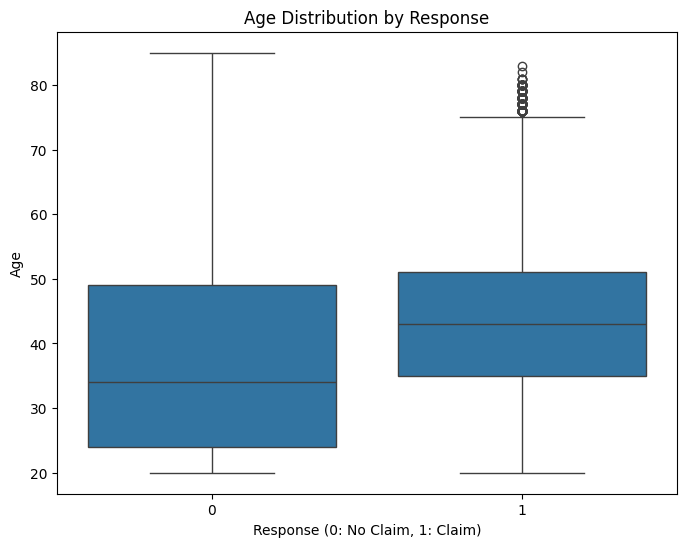

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Response', y='Age', data=df)
plt.title('Age Distribution by Response')
plt.xlabel('Response (0: No Claim, 1: Claim)')
plt.ylabel('Age')
plt.show()

## Analyze Gender vs. Claims

### Subtask:
Examine the relationship between 'Gender' and the target variable 'Response' (insurance claims) by creating a count plot that shows the distribution of 'Response' for each gender category. Ensure the plot has appropriate labels, title, and legend.

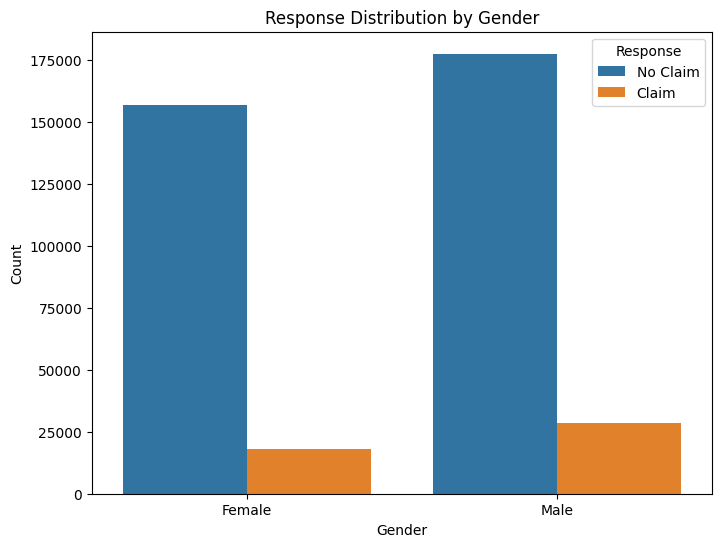

In [22]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', hue='Response', data=df)
plt.title('Response Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Response', labels=['No Claim', 'Claim'])
plt.show()

## Analyze Previously Insured vs. Claims

### Subtask:
Examine the relationship between 'Previously_Insured' and the target variable 'Response' (insurance claims) by creating a count plot that shows the distribution of 'Response' for customers who were previously insured and those who were not. Ensure the plot has appropriate labels, title, and legend.

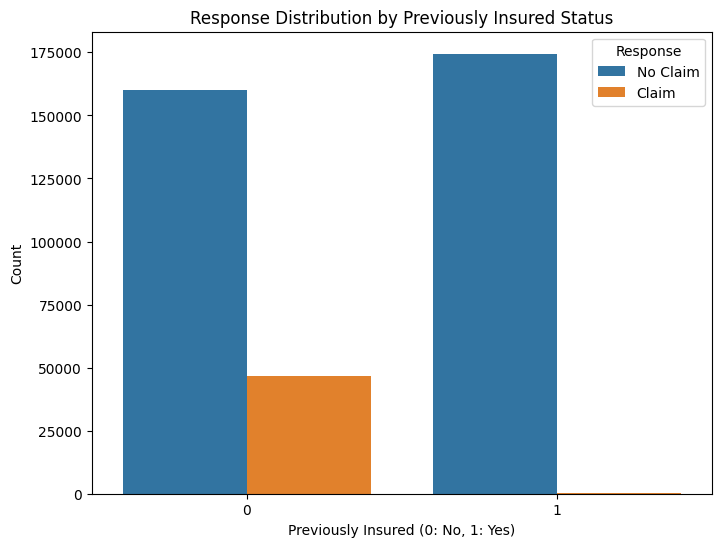

In [23]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Previously_Insured', hue='Response', data=df)
plt.title('Response Distribution by Previously Insured Status')
plt.xlabel('Previously Insured (0: No, 1: Yes)')
plt.ylabel('Count')
plt.legend(title='Response', labels=['No Claim', 'Claim'])
plt.show()

## Analyze Driving License vs. Claims

### Subtask:
Examine the relationship between 'Driving_License' and the target variable 'Response' (insurance claims) by creating a count plot that shows the distribution of 'Response' for customers with and without a driving license. Ensure the plot has appropriate labels, title, and legend.

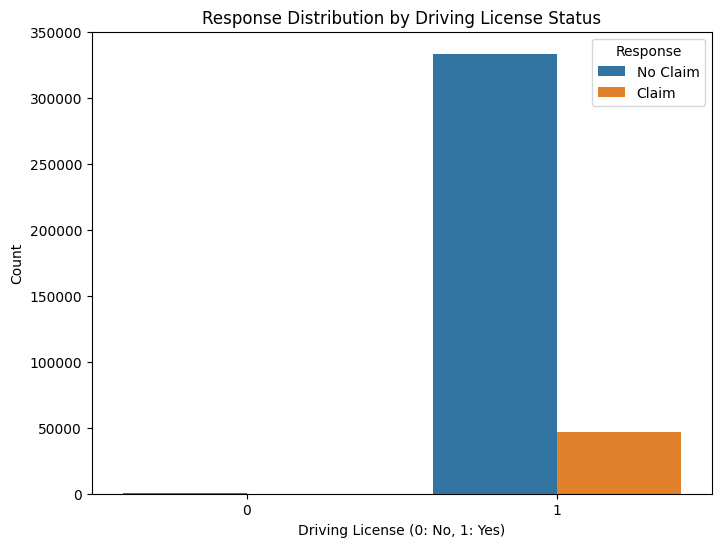

In [24]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Driving_License', hue='Response', data=df)
plt.title('Response Distribution by Driving License Status')
plt.xlabel('Driving License (0: No, 1: Yes)')
plt.ylabel('Count')
plt.legend(title='Response', labels=['No Claim', 'Claim'])
plt.show()

## Analyze Vehicle Age vs. Claims

### Subtask:
Examine the relationship between 'Vehicle_Age' and the target variable 'Response' (insurance claims) by creating a count plot that shows the distribution of 'Response' for each vehicle age category. Ensure the plot has appropriate labels, title, and legend.

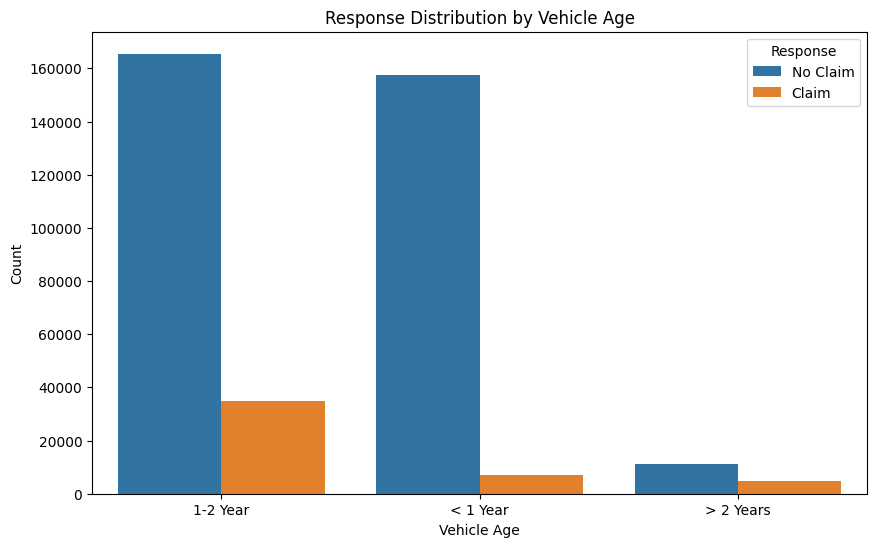

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Vehicle_Age', hue='Response', data=df, order=df['Vehicle_Age'].value_counts().index)
plt.title('Response Distribution by Vehicle Age')
plt.xlabel('Vehicle Age')
plt.ylabel('Count')
plt.legend(title='Response', labels=['No Claim', 'Claim'])
plt.show()

## Analyze Vehicle Damage vs. Claims

### Subtask:
Examine the relationship between 'Vehicle_Damage' and the target variable 'Response' (insurance claims) by creating a count plot that shows the distribution of 'Response' for vehicles with and without damage. Ensure the plot has appropriate labels, title, and legend.

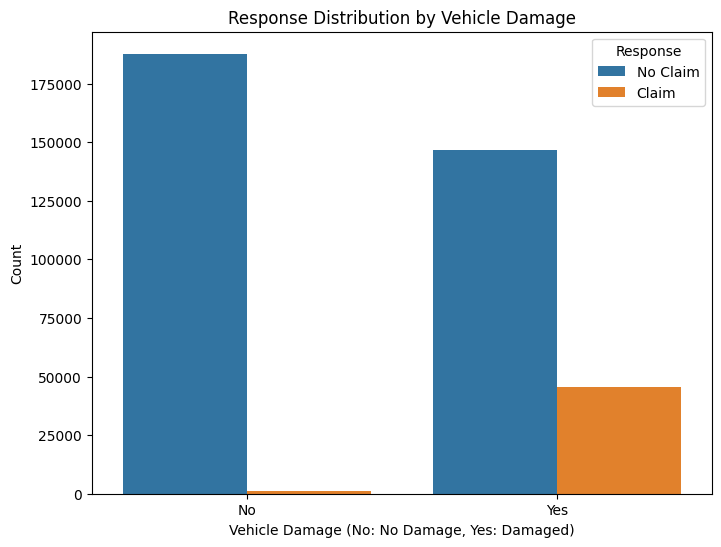

In [26]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Vehicle_Damage', hue='Response', data=df)
plt.title('Response Distribution by Vehicle Damage')
plt.xlabel('Vehicle Damage (No: No Damage, Yes: Damaged)')
plt.ylabel('Count')
plt.legend(title='Response', labels=['No Claim', 'Claim'])
plt.show()

## Analyze Annual Premium vs. Claims

### Subtask:
Examine the relationship between 'Annual_Premium' and the target variable 'Response' (insurance claims) by creating a box plot that shows the distribution of 'Annual_Premium' for each 'Response' category. Ensure the plot has appropriate labels, title, and legend.

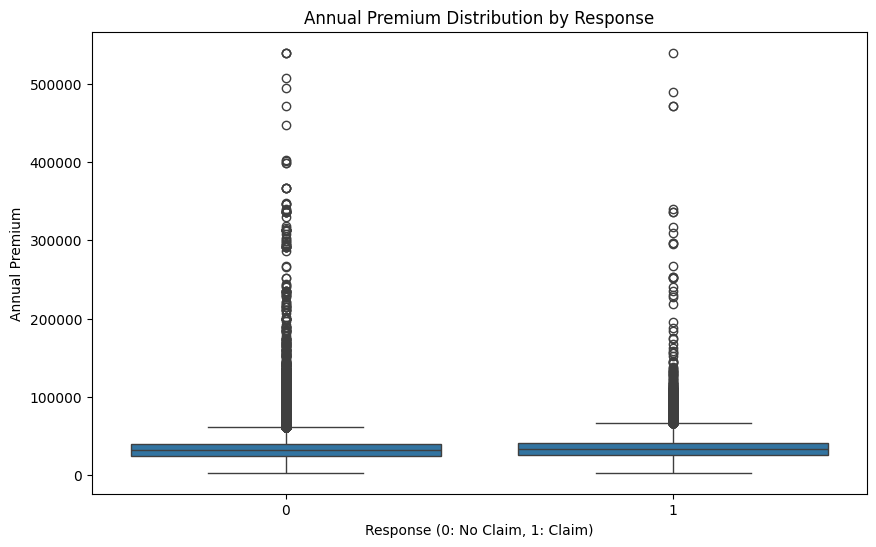

In [27]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Response', y='Annual_Premium', data=df)
plt.title('Annual Premium Distribution by Response')
plt.xlabel('Response (0: No Claim, 1: Claim)')
plt.ylabel('Annual Premium')
plt.show()

## Analyze Region vs. Claims

### Subtask:
Analyze regional patterns in insurance claims ('Response') by calculating and visualizing claim rates for different 'Region_Code' values. This might involve a bar chart of claim rates per region, with labels and legends.


/tmp/ipykernel_642/2203539290.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  claim_rate_by_region = df.groupby('Region_Code')['Response'].mean().reset_index()


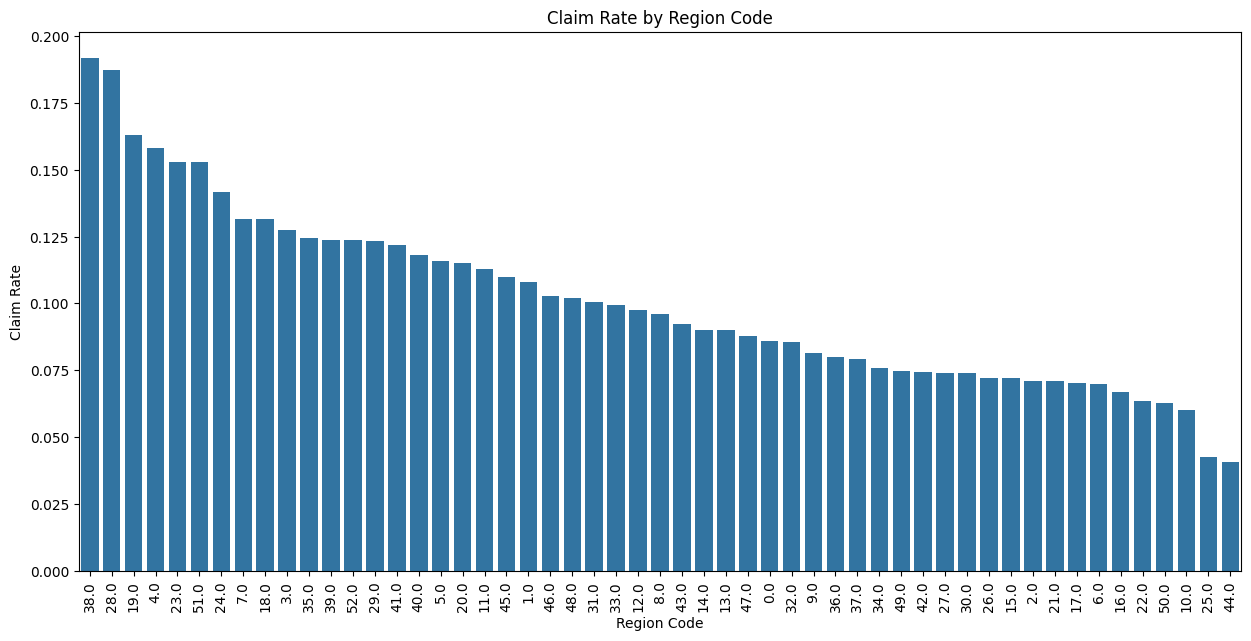

In [28]:
claim_rate_by_region = df.groupby('Region_Code')['Response'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.barplot(x='Region_Code', y='Response', data=claim_rate_by_region, order=claim_rate_by_region.sort_values('Response', ascending=False)['Region_Code'])
plt.title('Claim Rate by Region Code')
plt.xlabel('Region Code')
plt.ylabel('Claim Rate')
plt.xticks(rotation=90)
plt.show()

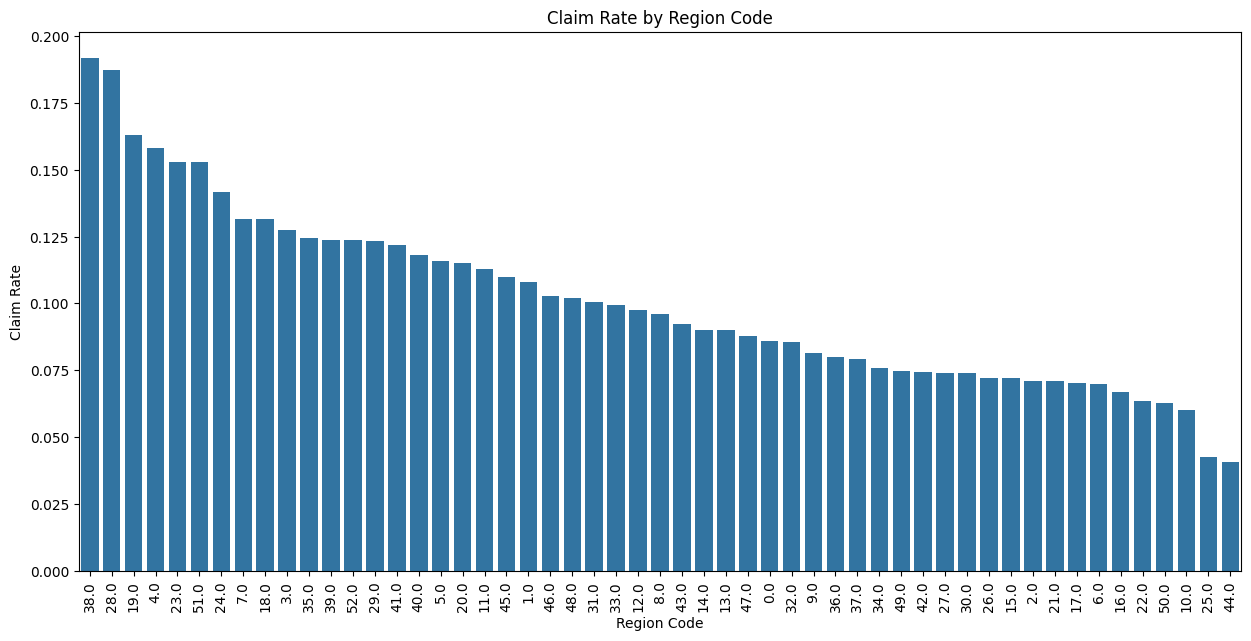

In [29]:
claim_rate_by_region = df.groupby('Region_Code', observed=False)['Response'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.barplot(x='Region_Code', y='Response', data=claim_rate_by_region, order=claim_rate_by_region.sort_values('Response', ascending=False)['Region_Code'])
plt.title('Claim Rate by Region Code')
plt.xlabel('Region Code')
plt.ylabel('Claim Rate')
plt.xticks(rotation=90)
plt.show()

## Analyze Policy Sales Channel vs. Claims

### Subtask:
Explore the impact of different 'Policy_Sales_Channel' on claim likelihood ('Response') using a visualization such as a bar chart comparing claim rates across channels, with labels and legends.


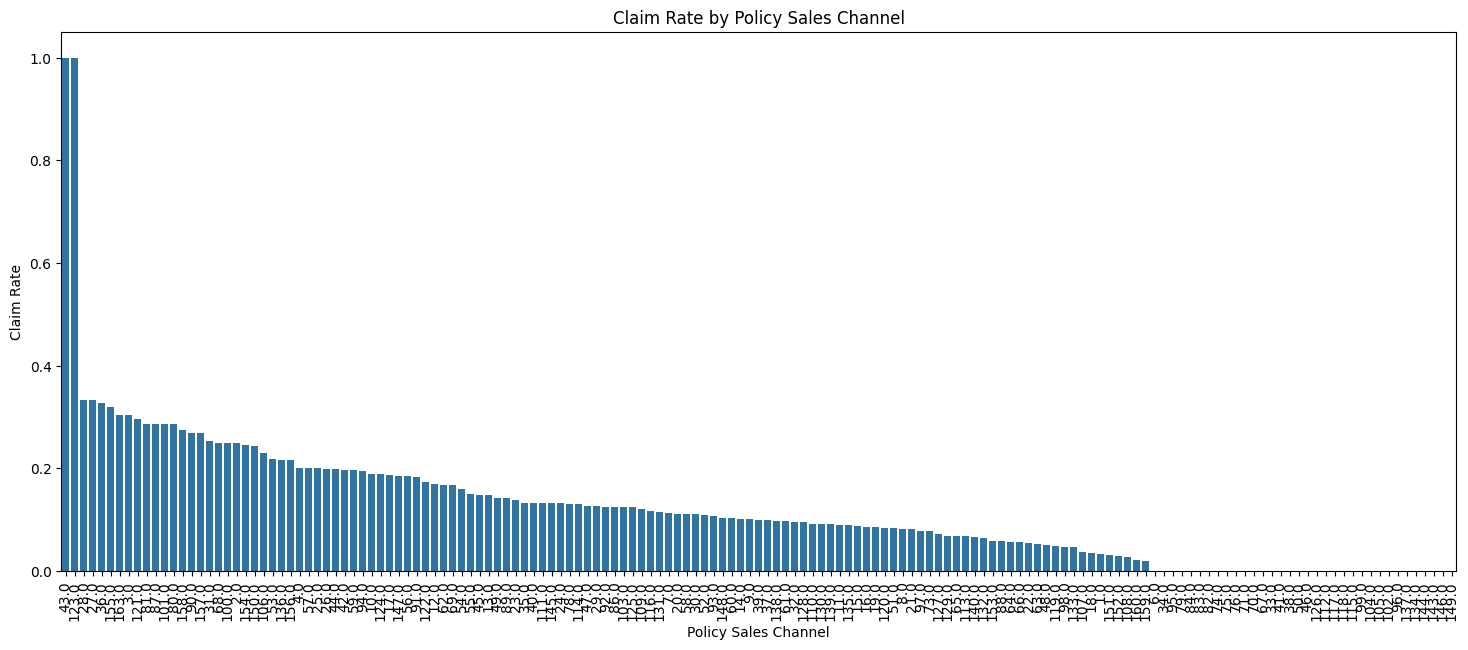

In [30]:
claim_rate_by_channel = df.groupby('Policy_Sales_Channel', observed=False)['Response'].mean().reset_index()

plt.figure(figsize=(18, 7))
sns.barplot(x='Policy_Sales_Channel', y='Response', data=claim_rate_by_channel, order=claim_rate_by_channel.sort_values('Response', ascending=False)['Policy_Sales_Channel'])
plt.title('Claim Rate by Policy Sales Channel')
plt.xlabel('Policy Sales Channel')
plt.ylabel('Claim Rate')
plt.xticks(rotation=90)
plt.show()

## Final Task

### Subtask:
Provide a summary of the key findings and insights derived from the entire Exploratory Data Analysis, highlighting significant patterns, trends, and factors influencing insurance claims.


## Summary (Shortened Version):

### Data Analysis Key Findings

*   **Dataset Overview**: Our dataset, covering over 380,000 vehicle insurance entries, was complete with no missing values. We observed that roughly 12% of customers filed a claim.

*   **Key Predictors**: `Previously_Insured` and `Vehicle_Damage` emerged as extremely strong indicators for predicting claims. Customers previously insured rarely claimed, while those with vehicle damage showed a high propensity to claim.

*   **Numerical Features**: `Annual_Premium` and `Vintage` showed wide ranges and significant outliers. `Annual_Premium` specifically benefited from logarithmic scaling to reveal its distribution more clearly.

*   **Demographics and Claims**: Age distribution was skewed, with claimants generally being slightly younger. Gender itself didn't show a strong direct impact on claim rates. Regional codes and policy sales channels, however, exhibited varied claim rates, suggesting their influence.

These findings highlight critical areas for further investigation and model building, especially focusing on `Previously_Insured` and `Vehicle_Damage`.